# AM2061/AM6004: Assignment 1

## Submission

This assignment must be **your own work**. Remember the Academic Integrity Policy that you agreed to (near the top of the 2026-AM2061-AM6004 Modules page on Canvas).

Please submit your assignment electronically:
- Save the notebook (*studentID*_A1.ipynb).
- Upload the notebook to the Assignment 1 submission on Canvas.

**If you submit this assignment in late or to the wrong location, a mark of zero will be recorded unless you make a case for mitigation by submitting supporting documentation (e.g. medical certificates) to the School of Mathematical Sciences Office <sms@ucc.ie>.**


*Note: For this assignment you should only ever import math, NumPy and Matplotlib.* 

*Be sure to provide comments for crucial lines of code stating their function.*

Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and student ID below:

In [53]:
NAME = "Kevin O'Reilly"
ID = "120462952"

In [54]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math

## Newton-Raphson method (10 marks)

Below is a simple (rescaled/non-dimensionalised) model for the Earth's average surface temperature $T(t)$ 
$$\frac{dT}{dt} = -T + b + c\tanh\left(T\right),$$
where $c>0$. The first term is related to the greenhouse effect, the second term is related to incoming solar radiation and the third is related to the Earth's albedo (i.e. ability to reflect solar radiation). 

In order to analyse and understand the behaviour of the Earth's climate, it is helpful to find its so-called 'steady-states'. These are special values of $T(t)$ for which the global average temperature stays at that value as $t\rightarrow\infty$. They are found by solving the equation $\frac{dT}{dt}=0$, that is,

$$f(T) = -T + b + c\tanh\left(T\right) = 0$$

Give a Python implementation of the Newton-Raphson method to find the steady-states of the Earth's climate for the cases below. In other words, solve $f(T)=0$. Let accuracy tolerance $TOL$ and maximum number of iterations $N_0$ be parameters of the method. Print the approximated root at every iteration step.

Begin by defining a Python function for the Newton-Raphson method.

In [55]:
def newton(f, f_prime, p0, TOL, N0):
    '''Newton-Raphson method to find a root of function f 
        using initial guess p0 
        within accuracy TOL
        within a maximum of N0 steps
        usage: newton(f, p0, TOL, N0)
          

    Parameters
    ----------
    f: function
    f_prime: function derivative
    p0: intial guess
    TOL: tolerance (absolute value)          
    N0: maximum number of steps
    
    Returns
    -------
    p_n : number

    Example (using the lambda function)
    -----------------------------------
    >>> a = 3.0
    >>> f = lambda x: x**2 - x - 2*a
    >>> f_prime = lambda x: 2*x - 1
    >>> newton(f, f_prime, 1.5, 1e-10, 25)
    3.0
    '''
    p = p0   
    for n in range(1, N0 + 1):
        p_new = p - f(p)/f_prime(p)
        print(f"Iteration {n}: {p_new}")
        if abs(p_new - p) < TOL:
            return p_new
        p = p_new
    print("Did not converge within maximum iterations")
    return p

Using the Newton-Raphson method with $TOL = 10^{-10}$ and $N_0 = 50$, find the steady-states of the neuron for the case of $b=-1.0$ and $c=2.5$ with the following initial guesses $p_0$.

In [56]:
b = -1.0
c = 2.5
f = lambda T: -T + b + c*np.tanh(T)
f_prime = lambda T: -1 + c*(1/np.cosh(T)**2)
TOL = 1e-10
N0 = 50

### Case A:
Initial guess $p_0=-10$.

In [57]:
newton(f, f_prime, -10, TOL, N0)

Iteration 1: -3.4999998557192438
Iteration 2: -3.49540290024026
Iteration 3: -3.495402705869634
Iteration 4: -3.4954027058696338


np.float64(-3.4954027058696338)

### Case B: 
Initial guess $p_0=-100$.

In [58]:
newton(f, f_prime, -100, TOL, N0)

Iteration 1: -3.5
Iteration 2: -3.4954029002524227
Iteration 3: -3.495402705869634
Iteration 4: -3.4954027058696338


np.float64(-3.4954027058696338)

### Case C: 
Initial guess $p_0=-1000$.

In [59]:
newton(f, f_prime, -1000, TOL, N0)

Iteration 1: -3.5
Iteration 2: -3.4954029002524227
Iteration 3: -3.495402705869634
Iteration 4: -3.4954027058696338


C:\Users\Kevin\AppData\Local\Temp\ipykernel_40128\1690092374.py:4: RuntimeWarning: overflow encountered in cosh
  f_prime = lambda T: -1 + c*(1/np.cosh(T)**2)


np.float64(-3.4954027058696338)

The initial guesses for cases A-C seem very different to each other. What do you observe about the number of iterations required for each case? Plot the function $f(T)$ and explain why this observation makes sense.  
*Note: No need to do any calculations*.

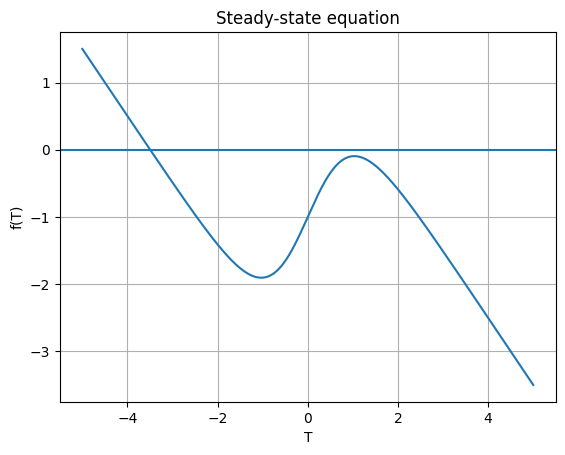

In [60]:
T = np.linspace(-5, 5, 1000)
plt.plot(T, f(T))
plt.axhline(0)   
plt.xlabel("T")
plt.ylabel("f(T)")
plt.title("Steady-state equation")
plt.grid(True)
plt.show()

Even though the initial guesses are very different in magnitude, they all converge in the same 4 iterations, starting near -3.5. This is because they are always relatively large negative numbers, where the function effectively becomes linear, making this method very stable from the left.

In [61]:
np.tanh(-10), np.tanh(-100), np.tanh(-1000)

(np.float64(-0.9999999958776927), np.float64(-1.0), np.float64(-1.0))

In [62]:
1/np.cosh(-10)**2, 1/np.cosh(-100)**2, 1/np.cosh(-1000)**2

C:\Users\Kevin\AppData\Local\Temp\ipykernel_40128\1710802016.py:1: RuntimeWarning: overflow encountered in cosh
  1/np.cosh(-10)**2, 1/np.cosh(-100)**2, 1/np.cosh(-1000)**2


(np.float64(8.244614455767398e-09),
 np.float64(5.535586106946949e-87),
 np.float64(0.0))

### Case D: 
Initial guess $p_0=-1.04$.

In [63]:
print("Case D")
newton(f, f_prime, -1.04, TOL, N0)


Case D
Iteration 1: -150.14201724537742
Iteration 2: -3.5
Iteration 3: -3.4954029002524227
Iteration 4: -3.495402705869634
Iteration 5: -3.4954027058696338


np.float64(-3.4954027058696338)

### Case E: 
Initial guess $p_0=-1.03$.

In [64]:
print("Case E")
newton(f, f_prime, -1.03, TOL, N0)


Case E
Iteration 1: 713.785238589311
Iteration 2: 1.5
Iteration 3: 1.06746640258704
Iteration 4: -0.7026429126009086
Iteration 5: 2.4127296269611165
Iteration 6: 1.3785494936180935
Iteration 7: 0.9751714486870122
Iteration 8: 2.0598815346389063
Iteration 9: 1.3005997704814445
Iteration 10: 0.8919931238731243
Iteration 11: 1.3721141243881712
Iteration 12: 0.9692554194411072
Iteration 13: 1.9540609554376096
Iteration 14: 1.2694941437887408
Iteration 15: 0.8489663462292769
Iteration 16: 1.2472583177936125
Iteration 17: 0.8127723474104024
Iteration 18: 1.1736770155174472
Iteration 19: 0.6326048737859555
Iteration 20: 0.9578199665507072
Iteration 21: 1.7962286408264723
Iteration 22: 1.2142954440829472
Iteration 23: 0.7469475752920662
Iteration 24: 1.0760303817068866
Iteration 25: -0.3663084919898554
Iteration 26: 0.9005157988965546
Iteration 27: 1.4048894677870218
Iteration 28: 0.9980668403831313
Iteration 29: 2.8105028040927413
Iteration 30: 1.4324193839462143
Iteration 31: 1.0200404425557

C:\Users\Kevin\AppData\Local\Temp\ipykernel_40128\1690092374.py:4: RuntimeWarning: overflow encountered in cosh
  f_prime = lambda T: -1 + c*(1/np.cosh(T)**2)


np.float64(1.5)

What do you observe in cases D and E? Describe why the results were so very different, despite the initial guesses being so very similar.  
*Hint: You can refer to your plot above, if it is helpful.*

Both initial guesses, while extremely similar produce a very different outcome. As visible from the plot above, a local minimum exists near -1. Because the slope is almost flat around -1.03 and -1.04, the derivative the method divides by is near 0. This causes a very large initial step. In case D, this produces a very large negative value, which we've seen previously is easy to converge from thereafter. In case E, though the initial point is very close to case D, the sign of its very small derivative is flipped, meaning its first iteration reaches a very large positive value from which it fails to converge.

Find an initial guess that leads to convergence towards the root with $|p_n - p|$ decreasing monotonically. How might this initial guess relate to Theorem 2.4?  
*Note: No need to do any calculations.*

In [65]:
newton(f, f_prime, -4, TOL, N0)

Iteration 1: -3.496635782870742
Iteration 2: -3.495402719917181
Iteration 3: -3.4954027058696338
Iteration 4: -3.4954027058696338


np.float64(-3.4954027058696338)

By starting sufficiently close to p at -4, in a region where the slope is much less than one and is negative, we see monotonic convergence